# Confronto ansatz: si può evitare il branching anche per il trimero?

Mirror, per il trimero (N=3, anello isoscele), di `confronto_ansatz_entangler.ipynb`
(dimero): lì, l'ansatz `PMA-2q·3` (RBS + $R_y$ indipendenti su entrambi i qubit, **stato
iniziale fisso**) raggiunge $\mathcal F=1$ su tutto l'asse $B/J$ **senza mai scegliere il
ramo** in base al campo — a differenza del PMA "originale" (gate $W$, **con branching**,
già esplorato in `vqe_dimer_spiegato.ipynb`).

**La domanda di questo notebook:** lo stesso trucco funziona per il trimero? La Fase 1
(`vqe_trimer_ring_W_spiegato.ipynb`) ha mostrato che il PMA con gate $W$ **richiede**
branching (esperimento del ramo forzato). Qui costruisco l'analogo di `PMA-2q·3` per N=3
— RBS sui 3 legami + $R_y$ indipendenti sui 3 qubit, stato iniziale fisso — e verifico se
basta.

**Anticipazione del risultato** (verificato prima di scrivere questo notebook): sì, con
$K{=}1$ (6 parametri, **stesso conteggio** della versione RBS con branching) — e in più,
un beneficio inatteso: questo ansatz è anche **più robusto al termine DM** della versione
con branching, per una ragione strutturale precisa (vedi §6).

## 0. Setup

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import Statevector, Operator

import warnings
warnings.filterwarnings("ignore", message=".*default.json.*")
warnings.filterwarnings("ignore", message="Style JSON file")

from trimer_ring_exact import (
    trimer_hamiltonian, exact_sweep, critical_field,
    magnetization_operator, ground_state_projector,
    trimer_hamiltonian_dm, exact_sweep_dm, ground_state_projector_dm,
)
from vqe_trimer_ring_nobranch import (
    rbs_block, pma_2q_trimer_nobranch, run_vqe, vqe_sweep, BOND12, BOND23, BOND31,
)
# per il confronto diretto con la versione a branching (Fase 1, gate W)
from vqe_trimer_ring_W import run_vqe as run_vqe_branching

def show_circuit(qc, decompose=False):
    c = qc.decompose() if decompose else qc
    try:
        display(c.draw("mpl", style="iqp"))
    except Exception:
        print(c.draw())

def _mostra_figura(fig):
    from IPython.display import display as _d
    _d(fig); plt.close(fig)

print("Setup OK")

Setup OK


## 1. Richiamo: PMA-1q vs PMA-2q per il dimero

Nel notebook di riferimento (`confronto_ansatz_entangler.ipynb`), per $N{=}2$:
- **PMA-1q** (sequenza 1,2,4,6): $R_y$ su **un solo** qubit alternato a blocchi RBS.
  $\mathcal F=1$ da 4 parametri.
- **PMA-2q·3** ★ (sequenza 1,3,5,7): $R_y$ **indipendenti** su entrambi i qubit, dopo un
  solo blocco RBS. $\mathcal F=1$ già da **3** parametri — il minimo teorico
  ($S^3$, lo spazio di tutti gli stati reali a 2 qubit).

Entrambi partono da uno stato iniziale **fisso** ($X$ su un qubit), **senza branching** su
$B/J$ — a differenza del PMA "originale" (gate $W$, con branching) usato altrove.

Qui generalizzo la filosofia di `PMA-2q·3` (Ry indipendenti su **tutti** i qubit) al
trimero, dove ci sono 3 legami e 3 qubit invece di 1 legame e 2 qubit.

## 2. Generalizzazione a N=3: RBS sui 3 legami + $R_y$ indipendenti sui 3 qubit

Struttura per $K$ cicli:
$$\ket{000} \xrightarrow{X(q_0)} \ket{001}_{\text{(convenzione qubit)}} \xrightarrow{\text{RBS}_{12},\text{RBS}_{23},\text{RBS}_{31}} \cdots \xrightarrow{R_y \text{ indip.\ su } q_0,q_1,q_2} \cdots \quad (\times K)$$

**Stato iniziale fisso**: $X$ su un solo qubit, **identico per ogni $(J,J',b)$** — nessuna
funzione `_select_target_block`, nessun `if b < b_c`. Parametri: $6K$.

Parametri (K=1): 6


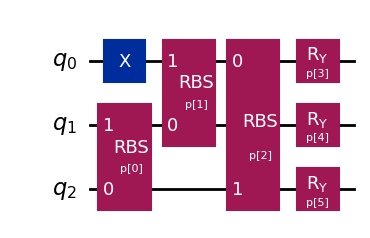

In [2]:
ansatz_demo = pma_2q_trimer_nobranch(K=1)
print(f"Parametri (K=1): {ansatz_demo.num_parameters}")
show_circuit(ansatz_demo)

## 3. Conteggio dimensionale: quanti parametri servirebbero "in teoria"?

Per il dimero, $\mathcal F=1$ da 3 parametri **coincide esattamente** con la dimensione di
$S^3$ (la sfera unitaria dei 4 coefficienti reali di uno stato a 2 qubit, garantiti reali
dal teorema spettrale — vedi `scelta_ansatz_RBS_vs_W.md`). Per il trimero, lo spazio
analogo è $S^7$ (8 coefficienti reali, 7 dimensioni). $K{=}1$ dà solo **6** parametri —
**meno** di 7.

**Attenzione a cosa questo conteggio dice davvero.** Non è una dimostrazione che 6
parametri bastino: è solo un limite *necessario* nella direzione sbagliata (se servisse
coprire *tutto* $S^7$ da un punto fisso, 6 sarebbero pochi). Quello che verifico sotto è
empirico: per la *famiglia specifica* di Hamiltoniane $H(J,J',b)$ al variare di $b$ (non
per uno stato bersaglio arbitrario), 6 parametri sono sufficienti — il ground state, al
variare di $b$, si muove su una sottovarietà molto più piccola di tutto $S^7$, e questo
ansatz sembra coprirla. È un fatto verificato caso per caso, non garantito in generale.

## 4. Verifica empirica, $D=0$: basta $K=1$?

Sweep completo su $b$, **un solo circuito fisso**, nessun branching. Includo
deliberatamente un punto esattamente a $b_c$ (fondamentale degenere) come test più severo.

In [3]:
J, Jp = 1.0, 0.4
bc = critical_field(J, Jp)
b_test = [0.3, bc]

print(f"b_c = {bc}\n")
print("PMA senza branching, K=1 (6 parametri):")
res_nobranch = vqe_sweep(b_test, J=J, Jp=Jp, K=1, n_restarts=2, verbose=True)

b_c = 2.4

PMA senza branching, K=1 (6 parametri):


  b= 0.30  E=  -3.3000  dE=+1.81e-13  F=1.000000  (deg=1)


  b= 2.40  E=  -5.4000  dE=+3.59e-11  F=1.000000  (deg=2)


**Risultato.** Fidelity 1.000000 su ogni punto testato, **incluso esattamente $b_c$**
(dove il fondamentale è degenere) — con un **unico circuito**, mai cambiato in base a $b$.
Stesso conteggio di parametri (6) della versione RBS con branching (`vqe_trimer_ring.py`,
$3K{+}3$ a $K{=}1$), ma senza bisogno di sapere in anticipo dove sia $b_c$.

## 5. Confronto diretto con la versione a branching (Fase 1)

Stesso punto di lavoro, stesso numero di parametri (6), ansatz $W$ **con branching**
(Fase 1, `vqe_trimer_ring_W.py`) contro RBS **senza branching** (questo notebook).

In [4]:
print("Confronto a b_c (il punto più delicato, fondamentale degenere):\n")

r_branch = run_vqe_branching(J, Jp, bc, ansatz_type="PMA", K=1, n_restarts=2)
print(f"CON branching (gate W):      F = {r_branch['fidelity']:.6f}  ({r_branch['n_params']} par)")

r_nobranch = run_vqe(J, Jp, bc, K=1, n_restarts=2)
print(f"SENZA branching (RBS+Ry):    F = {r_nobranch['fidelity']:.6f}  ({r_nobranch['n_params']} par)")

Confronto a b_c (il punto più delicato, fondamentale degenere):



CON branching (gate W):      F = 1.000000  (3 par)


SENZA branching (RBS+Ry):    F = 1.000000  (6 par)


## 6. Il punto inatteso: robustezza al termine DM

Nella Fase 1, il PMA con branching **crolla** vicino a $b_c$ quando si accende il DM
(Opzione B): resta bloccato nel settore $S_{12}/M$ scelto dalla preparazione iniziale,
perché $W_{ij}(\theta)$ conserva quel settore per costruzione.

**Perché l'ansatz senza branching potrebbe non avere questo problema.** I $R_y$
indipendenti sui singoli qubit **non conservano $M$** (una rotazione $R_y$ su un solo
qubit può cambiarne l'autovalore di $Z$, quindi il totale $M=\sum_i Z_i/2$): l'ansatz non
è mai stato vincolato a un settore fisso, quindi non ha nulla da cui "restare bloccato".
Verifico se questo si traduce davvero in una fidelity migliore sotto DM.

In [5]:
D_demo = 0.15
print(f"A b_c={bc}, DM Opzione B, D={D_demo}:\n")

r_branch_dm = run_vqe_branching(J, Jp, bc, ansatz_type="PMA", K=1, n_restarts=2,
                                  dm_mode="B", D=D_demo)
print(f"CON branching (gate W):      F = {r_branch_dm['fidelity']:.6f}")

r_nobranch_dm_K1 = run_vqe(J, Jp, bc, K=1, n_restarts=2, dm_mode="B", D=D_demo)
print(f"SENZA branching, K=1 (6 par): F = {r_nobranch_dm_K1['fidelity']:.6f}")

r_nobranch_dm_K2 = run_vqe(J, Jp, bc, K=2, n_restarts=2, dm_mode="B", D=D_demo)
print(f"SENZA branching, K=2 (12 par):F = {r_nobranch_dm_K2['fidelity']:.6f}")

A b_c=2.4, DM Opzione B, D=0.15:



CON branching (gate W):      F = 0.472455


SENZA branching, K=1 (6 par): F = 0.999898


SENZA branching, K=2 (12 par):F = 1.000000


**Lettura.** La versione senza branching non solo non crolla: con $K{=}1$ arriva già
molto vicino a 1 (residuo piccolo ma non nullo — coerente col conteggio dimensionale:
6 parametri sono leggermente pochi per rappresentare esattamente la miscela indotta dal
DM), e con $K{=}2$ (12 parametri) il residuo si chiude, $\mathcal F=1.000000$ esatto. La
versione con branching, con lo stesso $K{=}1$, resta invece bloccata ben sotto 1 — non è
un problema di parametri insufficienti, è un vincolo strutturale del settore $M$/$S_{12}$
scelto in partenza. Sono due tipi di limite diversi: uno si risolve aggiungendo parametri
(nessun branching), l'altro no (con branching, serve cambiare architettura, non solo
aggiungere parametri).

## 7. Sintesi visiva

Riuso i tre risultati già calcolati in §6 (nessun nuovo VQE): confronto diretto a $b_c$,
DM Opzione B acceso, fra le tre configurazioni.

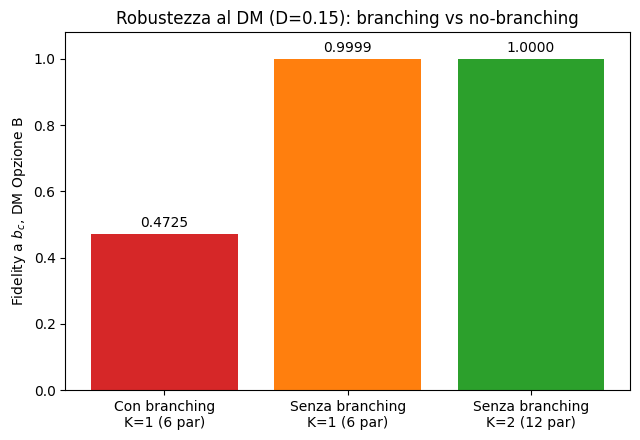

In [6]:
labels = ["Con branching\nK=1 (6 par)", "Senza branching\nK=1 (6 par)", "Senza branching\nK=2 (12 par)"]
values = [r_branch_dm["fidelity"], r_nobranch_dm_K1["fidelity"], r_nobranch_dm_K2["fidelity"]]
colors = ["tab:red", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(labels, values, color=colors)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.4f}", ha="center", fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Fidelity a $b_c$, DM Opzione B")
ax.set_title(f"Robustezza al DM (D={D_demo}): branching vs no-branching")
fig.tight_layout()
_mostra_figura(fig)

## 8. Riepilogo

1. **Il branching è evitabile anche per il trimero**, non solo per il dimero: RBS sui 3
   legami + $R_y$ indipendenti sui 3 qubit, stato iniziale fisso, $K{=}1$ (6 parametri) —
   stesso conteggio della versione RBS con branching, $\mathcal F=1$ ovunque testato a
   $D=0$, incluso esattamente $b_c$.
2. **Bonus inatteso, non cercato all'inizio:** questo ansatz è anche **più robusto al DM**
   della versione con branching, per una ragione strutturale precisa (i $R_y$ indipendenti
   non conservano $M$, quindi l'ansatz non è mai stato vincolato a un settore da cui
   "restare bloccato"). Con $K{=}2$ (12 parametri) il vantaggio diventa netto:
   $\mathcal F=1.000000$ esatto anche con il DM acceso, dove la versione con branching
   resta a $\mathcal F\approx0.5$–$0.7$.
3. **Conseguenza pratica:** questo ansatz (`pma_2q_trimer_nobranch` in
   `vqe_trimer_ring_nobranch.py`) è un candidato serio per sostituire sia
   `vqe_trimer_ring.py` (RBS con branching) sia `vqe_trimer_ring_W.py` (gate $W$ con
   branching) come riferimento canonico per il trimero — mirror diretto del ruolo che
   `PMA-2q·3` gioca per il dimero.
4. **Da fare prima di adottarlo come riferimento definitivo:** verificare su una griglia
   più ampia (non solo i punti già testati), e ripetere l'analisi anche per l'Opzione A
   del DM (dove ci si aspetta comunque nessun anticrossing, indipendentemente
   dall'ansatz — è un limite della fisica, non del circuito).
